## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.model_selection import train_test_split, KFold, learning_curve
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
import joblib
import warnings

warnings.filterwarnings("ignore", message="X does not have valid feature names")


## 2. Load data

In [2]:
df = pd.read_csv("vehicles.csv")
print(df.shape)


(426880, 26)


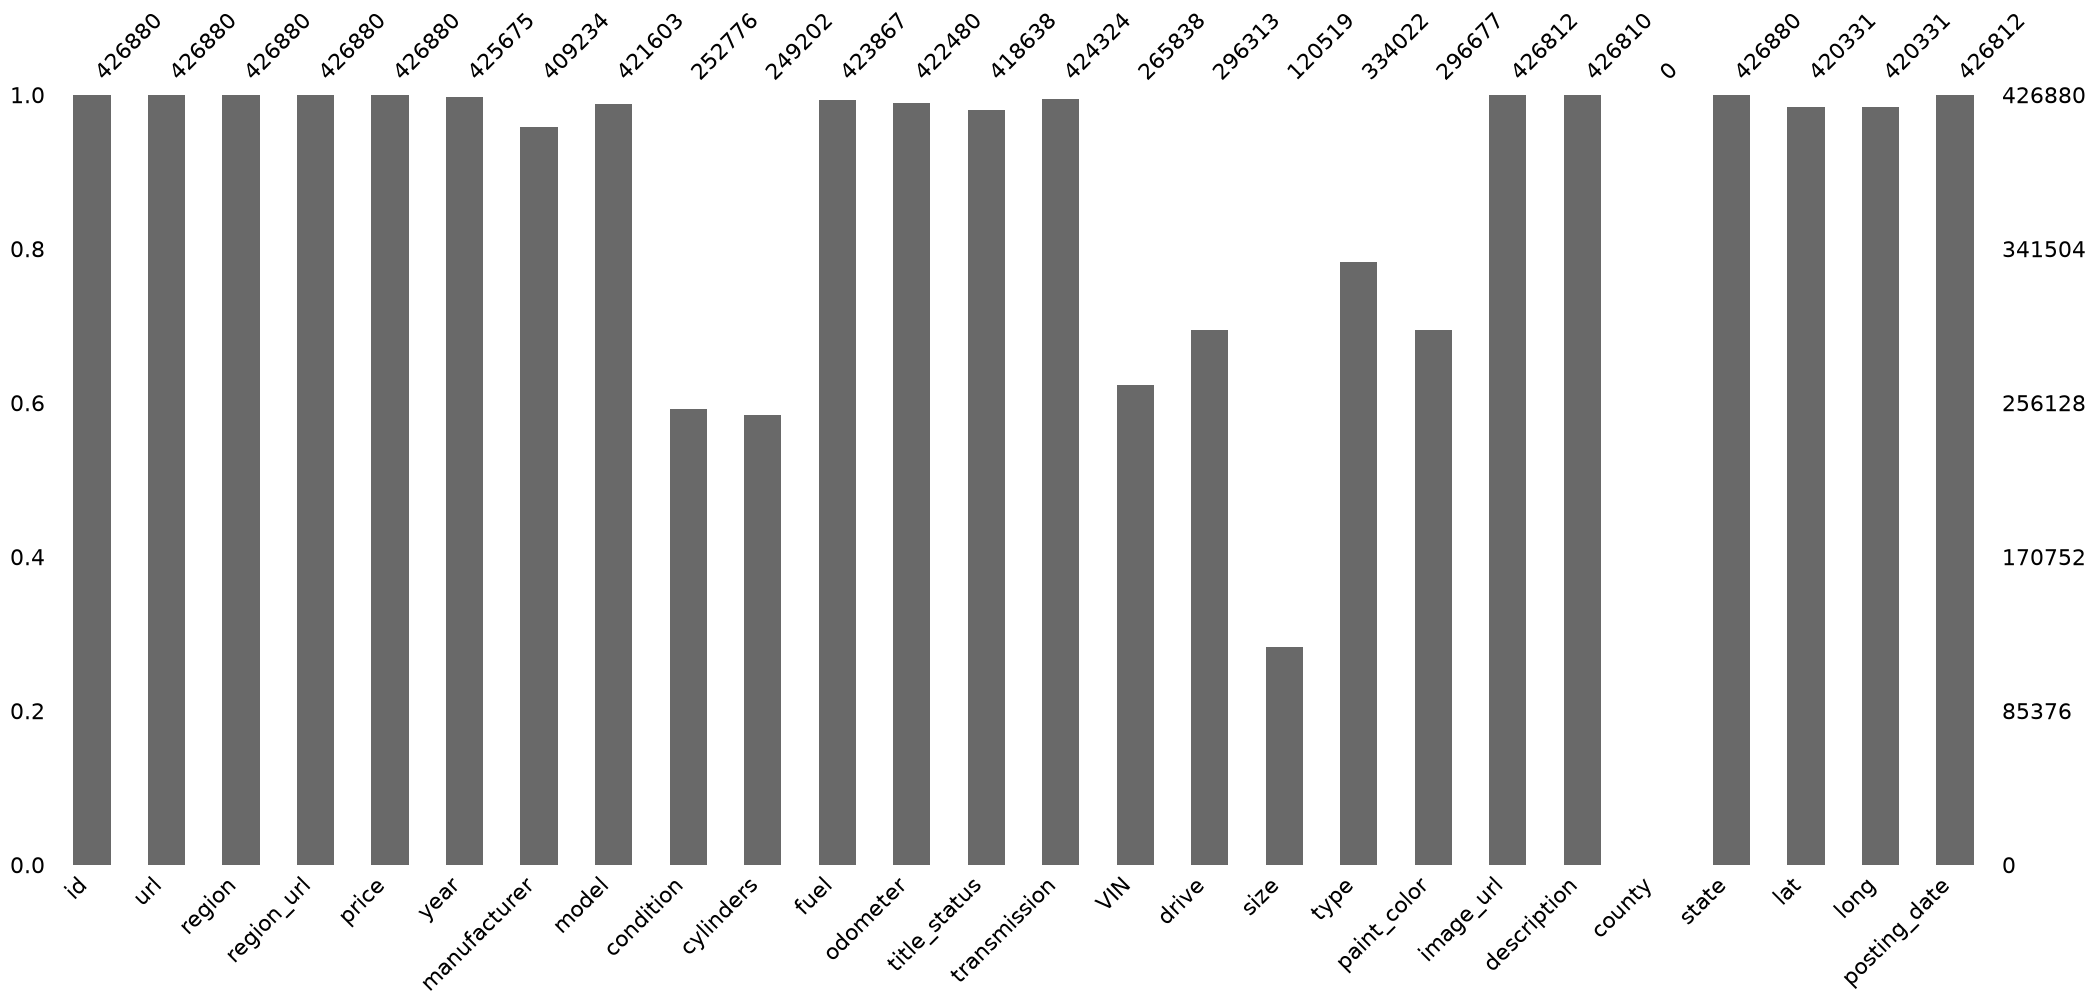

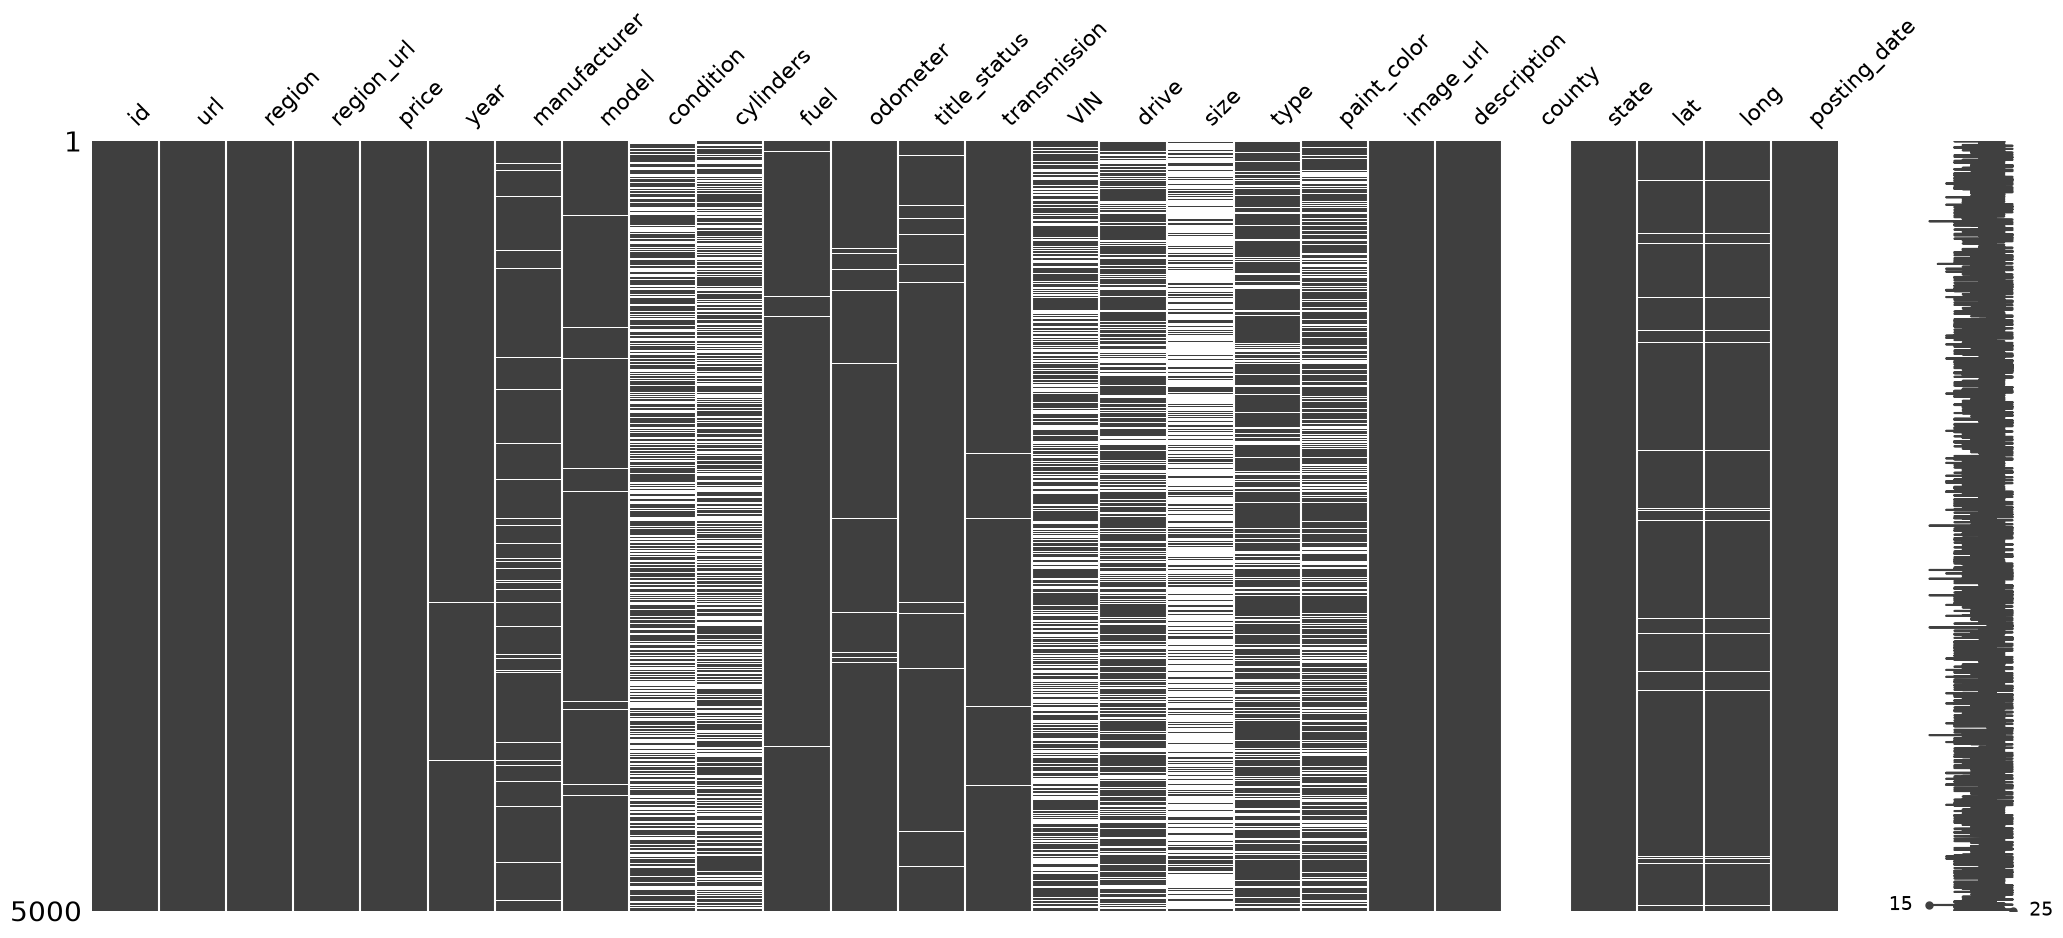

In [3]:
msno.bar(df)
plt.show()

msno.matrix(df.sample(5000, random_state=42))
plt.show()


In [4]:

print("Full duplicate rows:", df.duplicated().sum())


subset_cols = [c for c in df.columns if c not in ['price']]  
print("Duplicates (excluding price):", df.duplicated(subset=subset_cols).sum())


print(df['price'].value_counts().head(20))


dup_check = df[df.duplicated(subset=['manufacturer','model','odometer','year'], keep=False)]
print("Rows sharing same manufacturer/model/odometer/year:", dup_check.shape[0])

Full duplicate rows: 0
Duplicates (excluding price): 0
price
0        32895
6995      3169
7995      3129
9995      2867
8995      2837
4500      2778
5995      2727
3500      2716
29990     2705
6500      2594
5500      2584
10995     2390
7500      2351
25990     2320
27990     2228
2500      2204
4995      2190
26990     2112
11995     2112
12995     2109
Name: count, dtype: int64
Rows sharing same manufacturer/model/odometer/year: 248530


## 3. Drop Unneeded Columns & Rows Without a Target

In [5]:
columns_to_drop = ['county', 'size', 'VIN', 'lat', 'long', 'image_url',
                   'description', 'region_url', 'url', 'id', 'posting_date']
df.drop(columns=columns_to_drop, inplace=True, errors='ignore')


df = df.dropna(subset=['price'])


In [6]:
print("Before dedup:", df.shape)

df = df.drop_duplicates()
print("After removing full duplicates:", df.shape)


feature_cols = [c for c in df.columns if c != 'price']
df = df.drop_duplicates(subset=feature_cols, keep='first')
print("After removing near-duplicates (excl. price):", df.shape)

Before dedup: (426880, 15)
After removing full duplicates: (370389, 15)
After removing near-duplicates (excl. price): (365531, 15)


## 4. Train / Test Split

In [7]:
target_col = 'price'

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (255871, 14)  Test: (109660, 14)


In [8]:
small_missing_cols = ['year', 'fuel', 'odometer', 'transmission', 'title_status']

def basic_dropna(frame_X, frame_y, cols):
    mask = frame_X[cols].notna().all(axis=1)
    return frame_X[mask].copy(), frame_y[mask].copy()

X_train, y_train = basic_dropna(X_train, y_train, small_missing_cols)
X_test, y_test = basic_dropna(X_test, y_test, small_missing_cols)

for frame in (X_train, X_test):
    frame['cylinders'] = frame['cylinders'].astype(str).str.extract(r'(\d+)')[0]
    frame['cylinders'] = pd.to_numeric(frame['cylinders'], errors='coerce')


group_modes = {}
for col in ['cylinders', 'drive', 'type']:
    modes = (
        X_train.groupby(['manufacturer', 'model'])[col]
        .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan)
    )
    group_modes[col] = modes

global_modes = {
    col: (X_train[col].mode().iloc[0] if not X_train[col].mode().empty else np.nan)
    for col in ['cylinders', 'drive', 'type']
}

def fill_group_mode(frame, col):
    key = list(zip(frame['manufacturer'], frame['model']))
    mapped = pd.Series(key, index=frame.index).map(group_modes[col].to_dict())
    filled = frame[col].fillna(mapped)

    filled = filled.fillna(global_modes[col])
    return filled

for frame in (X_train, X_test):
    for col in ['cylinders', 'drive', 'type']:
        frame[col] = fill_group_mode(frame, col)


for name, frame_pair in [('train', (X_train, y_train)), ('test', (X_test, y_test))]:
    pass

def final_dropna(frame_X, frame_y):
    mask = frame_X[['manufacturer', 'model', 'cylinders']].notna().all(axis=1)
    return frame_X[mask].copy(), frame_y[mask].copy()

X_train, y_train = final_dropna(X_train, y_train)
X_test, y_test = final_dropna(X_test, y_test)


condition_mode = X_train['condition'].mode().iloc[0]
for frame in (X_train, X_test):
    frame['condition_missing'] = frame['condition'].isna().astype(int)
    frame['condition'] = frame['condition'].fillna(condition_mode)


for frame in (X_train, X_test):
    frame['paint_color'] = frame['paint_color'].fillna('unknown')

print("Train shape after cleaning:", X_train.shape)
print("Test shape after cleaning :", X_test.shape)


Train shape after cleaning: (234354, 15)
Test shape after cleaning : (100564, 15)


In [9]:
def get_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr


train_mask = (
    (y_train >= 500) & (y_train <= 150000)
    & (X_train['odometer'] < 400000)
    & (X_train['year'] >= 1995)
)
X_train, y_train = X_train[train_mask], y_train[train_mask]

test_mask = (
    (y_test >= 500) & (y_test <= 150000)
    & (X_test['odometer'] < 400000)
    & (X_test['year'] >= 1995)
)
X_test, y_test = X_test[test_mask], y_test[test_mask]


price_low, price_high = get_bounds(y_train)
odo_low, odo_high = get_bounds(X_train['odometer'])

def apply_iqr(X_frame, y_frame):
    mask = (
        (y_frame >= price_low) & (y_frame <= price_high)
        & (X_frame['odometer'] >= odo_low) & (X_frame['odometer'] <= odo_high)
    )
    return X_frame[mask], y_frame[mask]

X_train, y_train = apply_iqr(X_train, y_train)
X_test, y_test = apply_iqr(X_test, y_test)

print("Train after outlier removal:", X_train.shape)
print("Test after outlier removal :", X_test.shape)


Train after outlier removal: (202587, 15)
Test after outlier removal : (87007, 15)


In [10]:

def remove_scam_like(X_frame, y_frame):
    suspicious = (
        (X_frame['year'] >= 2012) &
        (X_frame['odometer'] < 150000) &
        (y_frame < 3000)
    )
    print(f"Removing {suspicious.sum()} likely scam/mispriced listings")
    return X_frame[~suspicious], y_frame[~suspicious]

X_train, y_train = remove_scam_like(X_train, y_train)
X_test, y_test = remove_scam_like(X_test, y_test)

Removing 1430 likely scam/mispriced listings
Removing 616 likely scam/mispriced listings


## 5. Feature Engineering


In [11]:
CURRENT_YEAR = 2026

for frame in (X_train, X_test):
    frame['car_age'] = (CURRENT_YEAR - frame['year']).clip(lower=0)
    frame['miles_per_year'] = frame['odometer'] / frame['car_age'].replace(0, 1)

print(X_train[['year', 'car_age', 'odometer', 'miles_per_year']].describe())


                year        car_age       odometer  miles_per_year
count  201157.000000  201157.000000  201157.000000   201157.000000
mean     2012.471835      13.528165   91422.273990     6420.989426
std         5.529754       5.529754   61708.035195     3570.402256
min      1995.000000       4.000000       0.000000        0.000000
25%      2009.000000       9.000000   36700.000000     3703.166667
50%      2014.000000      12.000000   86023.000000     6273.615385
75%      2017.000000      17.000000  135646.000000     8721.333333
max      2022.000000      31.000000  284110.000000    45000.000000


In [12]:


import joblib
import json

smoothing = 10
global_mean = float(y_train.mean())

encoding_maps = {
    "global_mean": global_mean,
    # global_modes was already computed in the "small_missing_cols" cell above
    "cylinders_fallback": float(global_modes["cylinders"]),
}

for col in ["region", "model"]:
    stats = y_train.groupby(X_train[col]).agg(["mean", "count"])
    smoothed = (stats["mean"] * stats["count"] + global_mean * smoothing) / (stats["count"] + smoothing)
    encoding_maps[col] = smoothed.to_dict()

joblib.dump(encoding_maps, "encoding_maps.pkl")

print("Saved encoding_maps.pkl")
print("region categories :", len(encoding_maps["region"]), "| sample keys:", list(encoding_maps["region"].keys())[:3])
print("model categories  :", len(encoding_maps["model"]), "| sample keys:", list(encoding_maps["model"].keys())[:3])
print("global_mean        :", encoding_maps["global_mean"])
print("cylinders_fallback :", encoding_maps["cylinders_fallback"])


MIN_COUNT = 15
MIN_PER_MANUFACTURER = 5

counts = X_train.groupby(["manufacturer", "model"]).size()

trimmed_models_by_manufacturer = {}
for manufacturer, sub in counts.groupby(level=0):
    sub = sub.droplevel(0).sort_values(ascending=False)
    keep = sub[sub >= MIN_COUNT]
    if len(keep) < MIN_PER_MANUFACTURER:
        keep = sub.head(MIN_PER_MANUFACTURER)
    trimmed_models_by_manufacturer[manufacturer] = sorted(keep.index.tolist())

total_before = counts.index.get_level_values("model").nunique()
total_after = sum(len(v) for v in trimmed_models_by_manufacturer.values())
print(f"\nModel dropdown options: {total_before} -> {total_after}")
print(f"(kept models with >= {MIN_COUNT} listings, or top {MIN_PER_MANUFACTURER} per manufacturer as a floor)")


with open("models_by_manufacturer_trimmed.js", "w", encoding="utf-8") as f:
    f.write("export const modelsByManufacturer = ")
    f.write(json.dumps(trimmed_models_by_manufacturer, indent=2, ensure_ascii=False))
    f.write(";\n")

print("Saved models_by_manufacturer_trimmed.js")

Saved encoding_maps.pkl
region categories : 404 | sample keys: ['SF bay area', 'abilene', 'akron / canton']
model categories  : 14887 | sample keys: ['(300)', '(cng) 2500 express van', '(s)port (s)edan']
global_mean        : 18918.654354558876
cylinders_fallback : 6.0

Model dropdown options: 14887 -> 1923
(kept models with >= 15 listings, or top 5 per manufacturer as a floor)
Saved models_by_manufacturer_trimmed.js


In [13]:
def kfold_target_encode(X_train, y_train, X_test, cols, n_splits=5, smoothing=10, seed=42):
    global_mean = y_train.mean()
    X_train_enc = X_train.copy()
    X_test_enc = X_test.copy()

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    for col in cols:
        oof = pd.Series(index=X_train.index, dtype=float)
        for tr_idx, val_idx in kf.split(X_train):
            tr_x, tr_y = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
            stats = tr_y.groupby(tr_x[col]).agg(['mean', 'count'])
            smoothed = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)
            oof.iloc[val_idx] = X_train[col].iloc[val_idx].map(smoothed).values
        oof = oof.fillna(global_mean)
        X_train_enc[col] = oof

      
        full_stats = y_train.groupby(X_train[col]).agg(['mean', 'count'])
        full_smoothed = (full_stats['mean'] * full_stats['count'] + global_mean * smoothing) / (full_stats['count'] + smoothing)
        X_test_enc[col] = X_test[col].map(full_smoothed).fillna(global_mean)

    return X_train_enc, X_test_enc

high_cardinality_cols = ['region', 'model']
X_train, X_test = kfold_target_encode(X_train, y_train, X_test, high_cardinality_cols)


In [14]:
num_cols = ['year', 'cylinders', 'odometer', 'car_age', 'miles_per_year']
ordinal_cols = ['condition']
condition_ordering = ['salvage', 'fair', 'good', 'excellent', 'like new', 'new']
categ_cols = ['fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color']
passthrough_cols = ['condition_missing', 'region', 'model']  

all_pipeline = ColumnTransformer(transformers=[
    ('num', Pipeline([('scaler', RobustScaler())]), num_cols),
    ('ord', Pipeline([('ordinal', OrdinalEncoder(
        categories=[condition_ordering], handle_unknown='use_encoded_value', unknown_value=-1
    ))]), ordinal_cols),
    ('cat', Pipeline([('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))]), categ_cols),
], remainder='passthrough')  


cols_order = num_cols + ordinal_cols + categ_cols + passthrough_cols
X_train_ord = X_train[cols_order]
X_test_ord = X_test[cols_order]

X_train_final = all_pipeline.fit_transform(X_train_ord, y_train)
X_test_final = all_pipeline.transform(X_test_ord)

print("Training data shape:", X_train_final.shape)
print("Test data shape    :", X_test_final.shape)


Training data shape: (201157, 46)
Test data shape    : (86391, 46)



XGBoost 
R2: 0.9051 | MAE: 2,574 | RMSE: 3,915


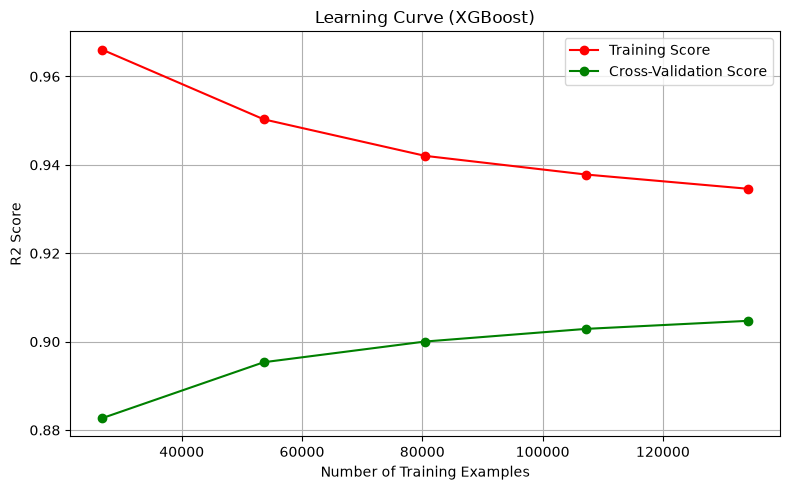

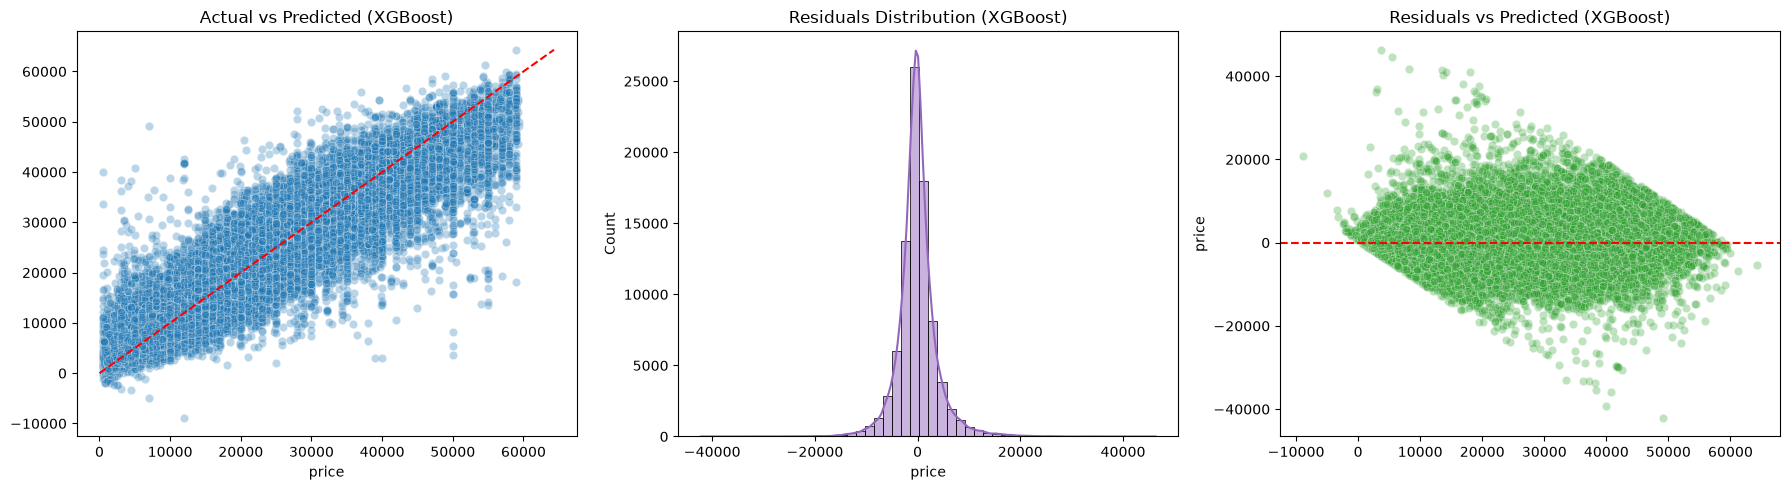


LightGBM 
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027432 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1165
[LightGBM] [Info] Number of data points in the train set: 201157, number of used features: 46
[LightGBM] [Info] Start training from score 18918.654355
R2: 0.8954 | MAE: 2,761 | RMSE: 4,108


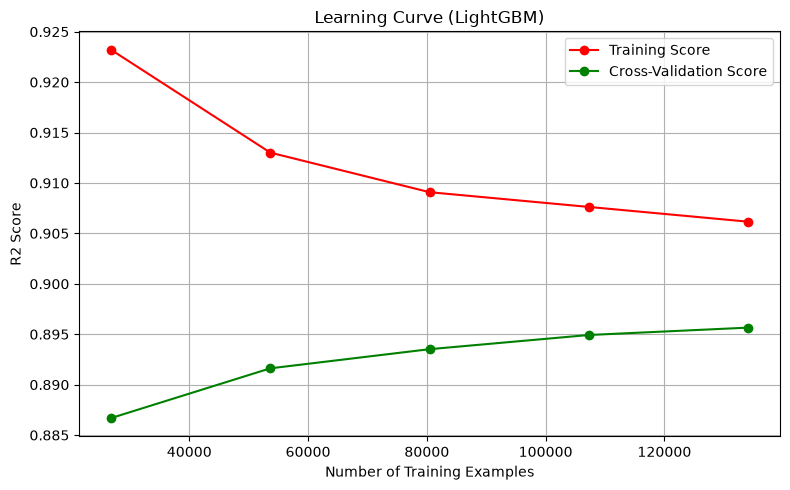

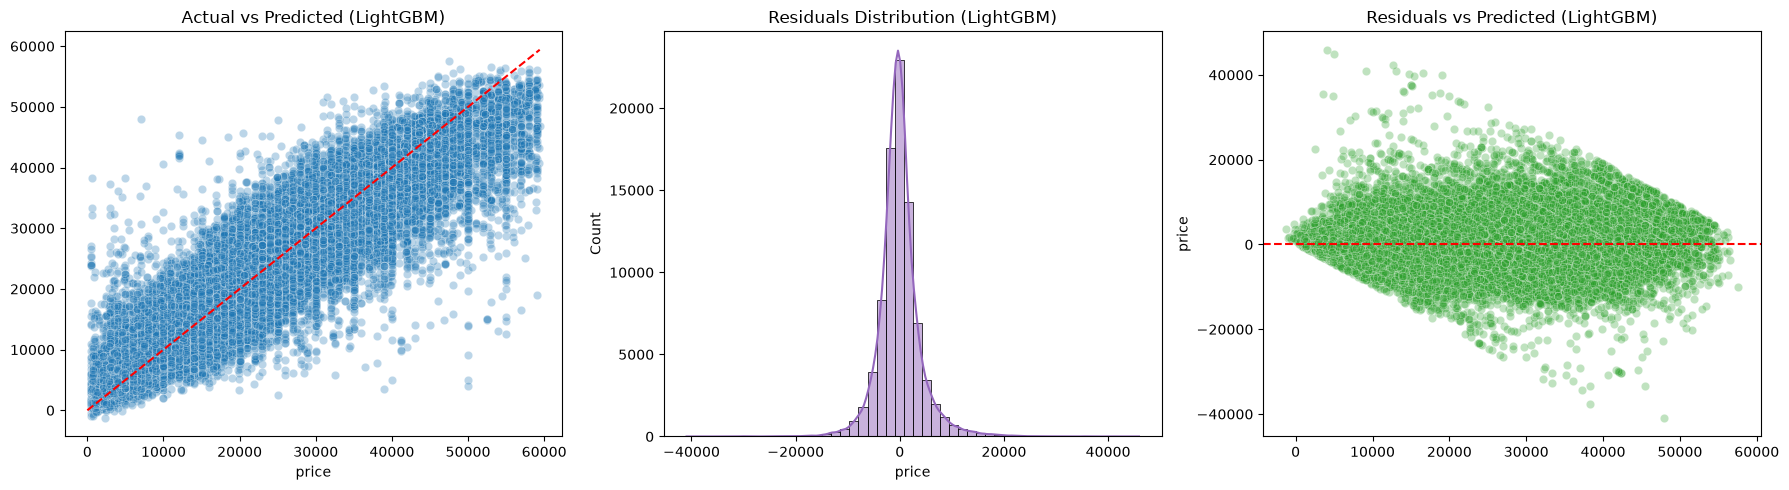

,r2,mae,rmse
XGBoost,0.905064,2574.437500,3914.566770
LightGBM,0.895425,2761.002522,4108.485832


In [15]:
models = {
    "XGBoost": XGBRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=300, random_state=42, n_jobs=-1),
}

results = {}

for name, model in models.items():
    print(f"\n{name} ")
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    print(f"R2: {r2:.4f} | MAE: {mae:,.0f} | RMSE: {rmse:,.0f}")
    results[name] = {"r2": r2, "mae": mae, "rmse": rmse}

    train_sizes_cv, train_scores_cv, val_scores_cv = learning_curve(
        estimator=model, X=X_train_final, y=y_train,
        train_sizes=np.linspace(0.2, 1.0, 5), cv=3, scoring='r2', n_jobs=-1
    )
    train_mean, val_mean = train_scores_cv.mean(axis=1), val_scores_cv.mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes_cv, train_mean, 'o-', color='r', label='Training Score')
    plt.plot(train_sizes_cv, val_mean, 'o-', color='g', label='Cross-Validation Score')
    plt.title(f"Learning Curve ({name})")
    plt.xlabel("Number of Training Examples"); plt.ylabel("R2 Score")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    residuals = y_test - y_pred
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.3, ax=axes[0])
    max_val = max(y_test.max(), y_pred.max())
    axes[0].plot([0, max_val], [0, max_val], 'r--')
    axes[0].set_title(f'Actual vs Predicted ({name})')

    sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='#9467bd')
    axes[1].set_title(f'Residuals Distribution ({name})')

    sns.scatterplot(x=y_pred, y=residuals, alpha=0.3, ax=axes[2], color='#2ca02c')
    axes[2].axhline(0, color='red', linestyle='--')
    axes[2].set_title(f'Residuals vs Predicted ({name})')
    plt.tight_layout(); plt.show()

pd.DataFrame(results).T


In [16]:
residuals = y_test - y_pred
low_actual_high_pred = (y_test < 5000) & (y_pred > 20000)

suspects = X_test[low_actual_high_pred].copy()
suspects['actual'] = y_test[low_actual_high_pred]
suspects['predicted'] = y_pred[low_actual_high_pred]

print("Number of suspected cases:", suspects.shape[0])
print(suspects['title_status'].value_counts(normalize=True))
print(suspects['condition'].value_counts(normalize=True))
print(suspects[['year','odometer','actual','predicted']].describe())

Number of suspected cases: 56
title_status
clean      0.928571
rebuilt    0.071429
Name: proportion, dtype: float64
condition
good         0.607143
like new     0.250000
excellent    0.125000
new          0.017857
Name: proportion, dtype: float64
              year       odometer       actual     predicted
count    56.000000      56.000000    56.000000     56.000000
mean   2013.267857   75588.517857  3052.696429  25781.195168
std       3.758583   45505.857818  1601.292227   4872.477380
min    2003.000000    1000.000000   500.000000  20087.245494
25%    2011.000000   39000.000000  1749.250000  22528.604018
50%    2014.000000   69929.000000  3500.000000  23905.562036
75%    2016.000000  101750.000000  4425.000000  27030.057149
max    2022.000000  190000.000000  4999.000000  38341.907151


In [17]:
print(X_test['title_status'].value_counts(normalize=True))

title_status
clean         0.963468
rebuilt       0.020754
salvage       0.010997
lien          0.003947
missing       0.000579
parts only    0.000255
Name: proportion, dtype: float64


In [ ]:
model = XGBRegressor(n_estimators=300, random_state=42, n_jobs=-1)
model.fit(X_train_final, y_train)    
y = model.predict(X_test_final)         
r2 = r2_score(y_test, y)
print(f"R2: {r2:.4f}")

R2: 0.9051


In [19]:



joblib.dump(all_pipeline, 'preprocessing_pipeline.pkl')

model.save_model("XGBR.json")

